# 초기 100사이클 배터리 수명 예측 — EDA

원본 139셀을 보존한다. `cycle_life`가 제공된 셀만 수명 회귀의 학습·평가에 사용한다. 제공 라벨이 관측 길이+1 이상이며 최종 QD가 0.885 Ah보다 높은 경우 우측 검열로 표시한다. 관측 종료 사이클을 수명으로 대체하지 않는다. Batch 1 중도 종료 10셀, Batch 2 라벨 결측 8셀, Batch 3 결측 2셀은 타깃 분석에서 제외한다. 이 제외는 예측 오차가 아니라 원본 라벨 존재 여부에 따른다.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
project = Path.cwd() if (Path.cwd() / 'src').is_dir() else Path.cwd().parent
sys.path.insert(0, str(project))
from src.features import load_cells, feature_matrix
from src.preprocess import DQ_FEATURES, policy_holdout, grouped_cv
cells = load_cells()
labelled = cells[cells.label_status == 'provided'].copy()


## 라벨 감사

`label_status=missing`은 측정 종료 시점만 알려져 정확한 수명 MAPE를 계산할 수 없는 셀이다. 일부 유효한 제공 라벨도 종료 조건에 대한 추가 검증이 필요할 수 있으므로, 이 결과를 저자 전처리 124셀 실험의 재현이라고 해석하지 않는다.

In [2]:
audit = cells.groupby('batch').agg(total_cells=('cell_id','size'), labelled_cells=('cycle_life','count'))
audit['excluded_targets'] = audit.total_cells - audit.labelled_cells
display(audit)
display(cells[cells.label_status != 'provided'][['cell_id','cycle_life','n_cycles','last_QD','charging_policy']])

,total_cells,labelled_cells,excluded_targets
batch,,,
Batch 1,46,36,10
Batch 2,47,39,8
Batch 3,46,44,2


,cell_id,cycle_life,n_cycles,last_QD,charging_policy
0,Batch 1-0,NaN,1189,1.026210,3.6C(80%)-3.6C
1,Batch 1-1,NaN,1178,1.038225,3.6C(80%)-3.6C
2,Batch 1-2,NaN,1176,1.043279,3.6C(80%)-3.6C
3,Batch 1-3,NaN,1225,0.970921,4C(80%)-4C
4,Batch 1-4,NaN,1226,1.021960,4C(80%)-4C
8,Batch 1-8,NaN,878,0.969025,5.4C(40%)-3.6C
10,Batch 1-10,NaN,905,0.961019,5.4C(50%)-3C
12,Batch 1-12,NaN,901,0.913119,5.4C(50%)-3.6C
13,Batch 1-13,NaN,896,0.923136,5.4C(50%)-3.6C
22,Batch 1-22,NaN,890,0.963279,6C(30%)-3.6C


## 수명 분포와 배치 이동

라벨이 없는 101사이클 관측 셀을 단수명 셀로 세지 않는다. Batch 2는 라벨이 있는 셀에서도 학습 배치보다 수명이 짧다.

,count,mean,min,max
batch,,,,
Batch 1,36,788.416667,534.0,1074.0
Batch 2,39,565.743590,392.0,1186.0
Batch 3,44,1059.659091,541.0,1935.0


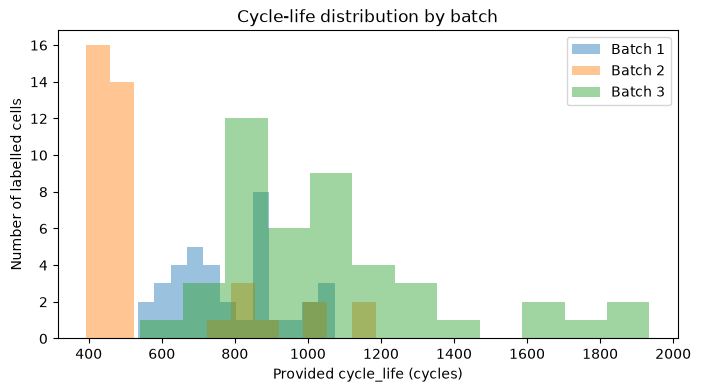

In [3]:
display(labelled.groupby('batch').cycle_life.agg(['count','mean','min','max']))
fig, ax = plt.subplots(figsize=(8,4))
for batch, part in labelled.groupby('batch'):
    ax.hist(part.cycle_life, bins=12, alpha=.45, label=batch)
ax.set(xlabel='Provided cycle_life (cycles)', ylabel='Number of labelled cells', title='Cycle-life distribution by batch')
ax.legend(); plt.show()

## ΔQ와 충전 정책

ΔQ는 모든 셀에서 `Qdlin(cycle=100) − Qdlin(cycle=10)`이다. 초기 용량과 관측 총 길이를 수명 대신 사용하지 않는다.

,,cycle_life,dq_var,dq_min,dq_mean,mean_chargetime,mean_Tavg
batch,,,,,,,
Batch 1,cycle_life,1.0,-0.801105,0.805061,0.767550,0.489712,-0.172708
Batch 2,cycle_life,1.0,-0.732787,0.818518,0.767085,0.087033,0.424616
Batch 3,cycle_life,1.0,-0.589654,0.692116,0.639115,0.637495,-0.021817


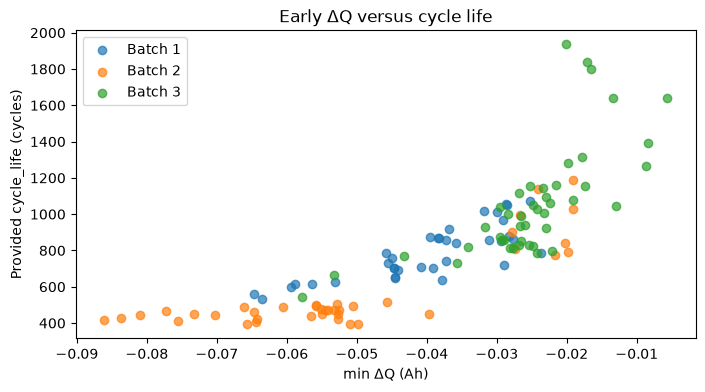

count     mean
batch   charging_policy                            
Batch 1 4.4C(80%)-4.4C                   1  1074.00
        4.8C(80%)-4.8C                   2   753.00
        5.4C(40%)-3.6C                   1  1054.00
        5.4C(50%)-3C                     1   788.00
        5.4C(60%)-3.6C                   2   859.50
        5.4C(60%)-3C                     2   799.50
        5.4C(70%)-3C                     2   739.50
        5.4C(80%)-5.4C                   2   546.50
        6C(30%)-3.6C                     1  1014.00
        6C(40%)-3.6C                     2   856.00
        6C(40%)-3C                       2   935.50
        6C(50%)-3.6C                     2   792.50
        6C(50%)-3C                       2   888.50
        6C(60%)-3C                       2   744.00
        7C(30%)-3.6C                     2   722.50
        7C(40%)-3.6C                     2   621.00
        7C(40%)-3C                       2   676.00
        8C(15%)-3.6C                     2  1008.50
        8C(25%)-3.6C                     2   676.50
        8C(35%)-3.6C                     2   607.50
Batch 2 3.6C(30%)-6C                     2   421.00
        3.6C(9%)-5C                      2   394.50
        4.65C(44%)-5C                    2   482.50
        4.65C(69%)-6C                    2   452.00
        4.8C(80%)-4.8C                   5   483.60
        4.8C(80%)-4.8C-newstructure      3   871.67
        5.2C(50%)-4.25C                  5   454.00
        5.2C(58%)-4C                     4   477.75
        5.2C(58%)-4C-newstructure        3   961.67
        5.6C(26%)-4.5C                   6   448.50
        5.6C(26%)-4.5C-newstructure      3   991.33
        6C(60%)-3C                       2   400.00
Batch 3 3.7C(31%)-5.9C-newstructure      3   660.00
        4.8C(80%)-4.8C-newstructure      6  1564.17
        5.3C(54%)-4C-newstructure        8  1074.38
        5.6C(19%)-4.6C-newstructure      8  1001.38
        5.6C(36%)-4.3C-newstructure      8   930.88
        5.9C(15%)-4.6C-newstructure      2   867.00
        5.9C(60%)-3.1C-newstructure      2   866.50
        5C(67%)-4C-newstructure          7  1105.71

In [4]:
display(labelled.groupby('batch')[['cycle_life'] + DQ_FEATURES + ['mean_chargetime','mean_Tavg']].corr().loc[(slice(None), 'cycle_life'), :])
fig, ax = plt.subplots(figsize=(8,4))
for batch, part in labelled.groupby('batch'):
    ax.scatter(part.dq_min, part.cycle_life, label=batch, alpha=.7)
ax.set(xlabel='min ΔQ (Ah)', ylabel='Provided cycle_life (cycles)', title='Early ΔQ versus cycle life')
ax.legend(); plt.show()
display(labelled.groupby(['batch','charging_policy']).cycle_life.agg(['count','mean']).round(2))

## 수정된 모델 전략

타깃은 `cycle_life` 회귀다. ΔQ 3개를 중심으로 원수명·로그 수명과 ΔQ 로그 통계 후보를 비교한다. MAPE 목적에 맞춰 내부 튜닝을 수행한다. Batch 1 정책 Hold-out으로 후보를 선택하며, 학습 분할 안의 외부·내부 CV도 정책 단위로 분리한다. Batch 2의 타깃 결측은 보간하지 않는다.

이미 Batch 2 결과를 보고 오류를 진단하며 전략을 수정한 개발 실험이다. 새로운 블라인드 테스트라고 주장하지 않는다. 최종 후보 선택 함수는 Batch 1 Hold-out MAPE만 사용한다.